# Dropout Risk Classification Model

This notebook trains a machine learning model to predict dropout risk.

Target variable: `dropout_risk` (binary proxy).

This proxy was engineered in `01_feature_engineering.ipynb`.

The model uses `RandomForestClassifier` with Stratified K-Fold Cross Validation (`k=5`).

The goal is to provide HR and leadership with early risk detection insights.

This model will later be exposed via:
- Backend ML endpoint (`/predict`)
- Dashboard risk panel
- Potential chatbot scoring logic

Reproducibility notes:
- Dataset path is loaded from `.env`
- Model path is loaded from `.env` (`MODEL_PATH`), with fallback if not defined

## Model Parameters & Rationale

Why RandomForest:
- Handles non-linear interactions
- Works well with small datasets
- Robust to feature scaling

Why StratifiedKFold:
- Preserves class balance in each fold

Why `class_weight="balanced"`:
- Compensates moderate class imbalance (approximately 63/37)

Chosen hyperparameters:
- `n_estimators=200`
- `max_depth=10`
- `min_samples_split=5`
- `min_samples_leaf=2`
- `random_state=42`

Metrics:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

This is an MVP model.

With only 100 samples, results must be interpreted cautiously.

In [1]:
# Import only allowed dependencies and standard libraries requested in the specification.
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate


def _find_project_root(start_path: str) -> str:
    """Find project root by walking up until .env and backend folder are present."""
    current = os.path.abspath(start_path)
    while True:
        env_candidate = os.path.join(current, '.env')
        backend_candidate = os.path.join(current, 'backend')
        if os.path.isfile(env_candidate) and os.path.isdir(backend_candidate):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            break
        current = parent
    raise ValueError('Could not locate project root containing .env and backend directory.')


def _read_env_value(env_file: str, key: str) -> str:
    """Read a single key from .env file without external dependencies."""
    if not os.path.isfile(env_file):
        return ''
    with open(env_file, 'r', encoding='utf-8') as f:
        for line in f:
            raw = line.strip()
            if not raw or raw.startswith('#') or '=' not in raw:
                continue
            k, v = raw.split('=', 1)
            if k.strip() == key:
                return v.strip().strip('"').strip("'")
    return ''


# Resolve project root and .env location.
project_root = _find_project_root(os.getcwd())
env_path = os.path.join(project_root, '.env')

# Read relevant paths from process env first, then fallback to .env values.
data_path = os.getenv('DATA_PATH') or _read_env_value(env_path, 'DATA_PATH')
engineered_data_dir = os.getenv('ENGINEERED_DATA_DIR') or _read_env_value(env_path, 'ENGINEERED_DATA_DIR') or 'backend/data/processed'

if not data_path:
    raise ValueError('DATA_PATH is not set in environment or .env')

# Resolve relative paths from project root for reproducible execution.
if not os.path.isabs(data_path):
    data_path = os.path.join(project_root, data_path)

if not os.path.isabs(engineered_data_dir):
    engineered_data_dir = os.path.join(project_root, engineered_data_dir)

# Load engineered dataset produced by 01_feature_engineering notebook.
processed_path = os.path.join(engineered_data_dir, 'survey_engineered.csv')

# Fallback strategy: derive processed folder from DATA_PATH if expected file is missing.
if not os.path.exists(processed_path):
    normalized_data_path = os.path.abspath(data_path).replace('\\', '/')
    expected_segment = '/backend/data/raw/'
    if expected_segment in normalized_data_path:
        backend_root = normalized_data_path.split(expected_segment)[0] + '/backend'
        processed_path = os.path.join(backend_root, 'data', 'processed', 'survey_engineered.csv')

if not os.path.exists(processed_path):
    raise FileNotFoundError(f'Engineered dataset not found at: {processed_path}')

df = pd.read_csv(processed_path)

if 'dropout_risk' not in df.columns:
    raise ValueError("Required target column 'dropout_risk' not found in engineered dataset")

print(f'Engineered dataset loaded from: {processed_path}')
print(f'Dataset shape: {df.shape}')
print(f'Dropout target distribution:\n{df["dropout_risk"].value_counts(dropna=False)}')

Engineered dataset loaded from: /workspaces/EvaluAI/backend/data/processed/survey_engineered.csv
Dataset shape: (100, 55)
Dropout target distribution:
dropout_risk
1    63
0    37
Name: count, dtype: int64


In [2]:
# Define target vector.
y = pd.to_numeric(df['dropout_risk'], errors='coerce').fillna(0).astype(int)

# Start from numeric columns only.
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()

# Exclude leakage and non-target binary outputs requested in the specification.
exclude_columns = {
    'dropout_risk',
    'dependency_risk_high',
    'motivation_improved'
}

# dependency_level is categorical in this dataset and is not used directly.
# id_empleado is explicitly removed if present.
feature_columns = [
    col for col in numeric_columns
    if col not in exclude_columns and col != 'id_empleado'
]

X = df[feature_columns].apply(pd.to_numeric, errors='coerce').fillna(0)

print(f'Number of features: {len(feature_columns)}')
print('First 15 feature names:')
print(feature_columns[:15])
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

Number of features: 45
First 15 feature names:
['edad', 'antiguedad_empresa', 'rol_tecnico', 'frecuencia_uso_ia', 'usa_chatgpt', 'usa_gemini', 'usa_copilot', 'usa_lms_ia', 'usa_otra_ia', 'prefiere_humano_vs_ia', 'nivel_integracion_ia', 'AT1_rendimiento', 'AT2_facilita_aprendizaje', 'AT3_facilidad_uso', 'AT4_integracion_positiva']
X shape: (100, 45)
y shape: (100,)


In [3]:
# Initialize RandomForestClassifier with requested reproducible configuration.
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Define stratified 5-fold cross-validation.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define requested evaluation metrics.
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

# Run cross-validation and keep both train and test scores for overfitting analysis.
cv_results = cross_validate(
    rf_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

print('Cross-validation completed successfully.')

Cross-validation completed successfully.


In [4]:
# Build a compact summary table with mean and standard deviation for each metric.
metric_names = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
summary_rows = []

for metric in metric_names:
    test_scores = cv_results[f'test_{metric}']
    train_scores = cv_results[f'train_{metric}']

    row = {
        'metric': metric,
        'test_mean': float(np.mean(test_scores)),
        'test_std': float(np.std(test_scores)),
        'train_mean': float(np.mean(train_scores)),
        'train_std': float(np.std(train_scores)),
        'train_test_gap': float(np.mean(train_scores) - np.mean(test_scores))
    }
    summary_rows.append(row)

cv_summary = pd.DataFrame(summary_rows).sort_values('metric').reset_index(drop=True)

# Pretty print with rounding for readability.
display_df = cv_summary.copy()
for col in ['test_mean', 'test_std', 'train_mean', 'train_std', 'train_test_gap']:
    display_df[col] = display_df[col].round(4)

print('Cross-validation summary (mean ± std):')
print(display_df.to_string(index=False))

# Highlight potential overfitting risk using train-test gap threshold.
max_gap = cv_summary['train_test_gap'].max()
if max_gap > 0.08:
    print(f'\nWarning: Potential overfitting risk detected (max train-test gap = {max_gap:.4f}).')
else:
    print(f'\nTrain-test gaps look controlled (max gap = {max_gap:.4f}).')

Cross-validation summary (mean ± std):
   metric  test_mean  test_std  train_mean  train_std  train_test_gap
 accuracy     0.9400    0.0735         1.0        0.0          0.0600
       f1     0.9538    0.0565         1.0        0.0          0.0462
precision     0.9275    0.0783         1.0        0.0          0.0725
   recall     0.9833    0.0333         1.0        0.0          0.0167
  roc_auc     0.9894    0.0134         1.0        0.0          0.0106

Train-test gaps look controlled (max gap = 0.0725).


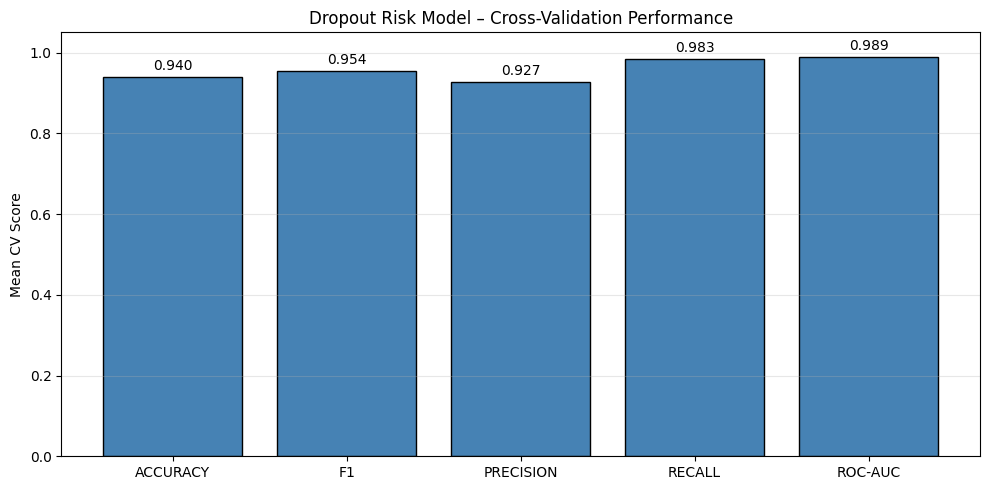

In [5]:
# Plot mean test metrics from cross-validation.
plot_df = cv_summary[['metric', 'test_mean']].copy()
plot_df['metric_label'] = plot_df['metric'].str.upper().replace({'ROC_AUC': 'ROC-AUC'})

plt.figure(figsize=(10, 5))
bars = plt.bar(plot_df['metric_label'], plot_df['test_mean'], color='steelblue', edgecolor='black')

# Add value labels above each bar for quick interpretation.
for bar, value in zip(bars, plot_df['test_mean']):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f'{value:.3f}', ha='center', va='bottom')

plt.ylim(0, 1.05)
plt.ylabel('Mean CV Score')
plt.title('Dropout Risk Model – Cross-Validation Performance')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# Train final model on the full dataset after cross-validation assessment.
final_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

final_model.fit(X, y)

# Extract and rank feature importances.
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

top_10_features = feature_importance_df.head(10).copy()

print('Top 10 features by importance:')
print(top_10_features.to_string(index=False))

Top 10 features by importance:
                 feature  importance
     self_efficacy_score    0.201641
  delta_motivation_score    0.116579
        motivation_score    0.108426
AE4_seguridad_aplicacion    0.066226
         dependency_risk    0.035521
 C1_confio_sin_verificar    0.030971
         M3_aporta_valor    0.025522
                    edad    0.023799
      M2_aumenta_interes    0.023625
   AE2_confianza_digital    0.023359


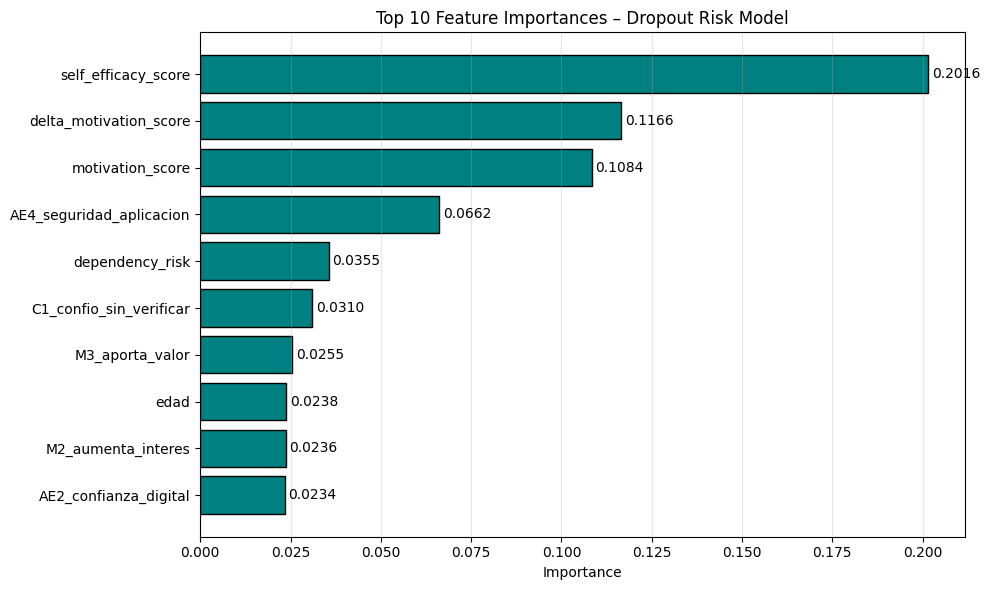

In [7]:
# Plot horizontal bar chart for top 10 feature importances.
plot_top = top_10_features.sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(plot_top['feature'], plot_top['importance'], color='teal', edgecolor='black')

# Add numeric labels next to bars.
for bar, value in zip(bars, plot_top['importance']):
    plt.text(value + 0.001, bar.get_y() + bar.get_height() / 2, f'{value:.4f}', va='center')

plt.xlabel('Importance')
plt.title('Top 10 Feature Importances – Dropout Risk Model')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Resolve model directory from environment first, then .env, then fallback.
model_dir = os.getenv('MODEL_PATH') or _read_env_value(env_path, 'MODEL_PATH') or 'backend/ml/models'

if not os.path.isabs(model_dir):
    model_dir = os.path.join(project_root, model_dir)

os.makedirs(model_dir, exist_ok=True)

# Save trained model artifact.
model_path = os.path.join(model_dir, 'dropout_risk_model.pkl')
joblib.dump(final_model, model_path)

# Prepare metadata payload for traceability and reproducibility.
cv_mean_metrics = {
    row['metric']: float(row['test_mean'])
    for _, row in cv_summary.iterrows()
}

metadata = {
    'model_type': 'RandomForestClassifier',
    'parameters': {
        'n_estimators': 200,
        'max_depth': 10,
        'min_samples_split': 5,
        'min_samples_leaf': 2,
        'class_weight': 'balanced',
        'random_state': 42
    },
    'n_features': int(X.shape[1]),
    'feature_names': X.columns.tolist(),
    'class_distribution': {
        str(k): int(v) for k, v in y.value_counts(dropna=False).to_dict().items()
    },
    'cross_validation_metrics': cv_mean_metrics,
    'timestamp': pd.Timestamp.utcnow().isoformat()
}

metadata_path = os.path.join(model_dir, 'dropout_risk_model_metadata.json')
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

print(f'Model saved to: {model_path}')
print(f'Metadata saved to: {metadata_path}')

Model saved to: /workspaces/EvaluAI/backend/ml/models/dropout_risk_model.pkl
Metadata saved to: /workspaces/EvaluAI/backend/ml/models/dropout_risk_model_metadata.json


## Final Summary & Usage

This notebook trains and validates a dropout risk classifier using stratified 5-fold cross-validation.

Key outputs:
- Cross-validation performance across Accuracy, Precision, Recall, F1, and ROC-AUC
- Train vs test gap analysis to inspect overfitting risk
- Top predictive features for dropout risk
- Saved model artifact and metadata for deployment

Interpretation guidance:
- Treat results as MVP-level evidence due to small sample size
- Feature importance provides directional insight, not causal proof

Model consumers:
- Backend API endpoint (`/predict`)
- HR dashboard risk alerts
- Future chatbot scoring layer

Lifecycle note:
- The model can be retrained when new survey waves are collected
- Future improvements should include threshold tuning and probability calibration